In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [38]:
DATA_PATH = r'D:\Machine Learning\taobao_behaviour\ECommerce_consumer_behaviour.csv'

# 1. Load du lieu tho

In [39]:
df = pd.read_csv(DATA_PATH)
df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_12660\2006162025.py:1: DtypeWarning: Columns (0: order_hour_of_day) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,department_id,department,product_name
0,2425083,49125,1,2,18,NaN,17,1,0,13,pantry,baking ingredients
1,2425083,49125,1,2,,NaN,91,2,0,16,dairy eggs,soy lactosefree
2,2425083,49125,1,2,18,NaN,36,3,0,16,dairy eggs,butter
3,2425083,49125,1,2,18,NaN,83,4,0,4,produce,fresh vegetables
4,2425083,49125,1,2,18,NaN,83,5,0,4,produce,fresh vegetables


In [40]:
df.shape

(1048575, 12)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                1048575 non-null  int64  
 1   user_id                 1048575 non-null  int64  
 2   order_number            1048575 non-null  int64  
 3   order_dow               1048575 non-null  int64  
 4   order_hour_of_day       1048575 non-null  object 
 5   days_since_prior_order  983854 non-null   float64
 6   product_id              1048575 non-null  int64  
 7   add_to_cart_order       1048575 non-null  int64  
 8   reordered               1048575 non-null  int64  
 9   department_id           1048575 non-null  int64  
 10  department              1048575 non-null  str    
 11  product_name            1048575 non-null  str    
dtypes: float64(1), int64(8), object(1), str(2)
memory usage: 96.0+ MB


In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.columns

Index(['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'product_id', 'add_to_cart_order',
       'reordered', 'department_id', 'department', 'product_name'],
      dtype='str')

# 2. Kiem tra cha luong du lieu

In [44]:
print('Giá trị order_hour_of_day bất thường (không parse được thành số):')
tmp = df['order_hour_of_day'].str.strip()
bad_mask = pd.to_numeric(tmp, errors='coerce').isna()
print(df.loc[bad_mask, 'order_hour_of_day'].value_counts())

Giá trị order_hour_of_day bất thường (không parse được thành số):
order_hour_of_day
10    85322
11    83172
15    81414
14    81261
13    81230
12    79662
16    76563
9     72977
17    63261
8     51816
18    49329
19    39184
20    29838
7     26207
21    23908
22    18975
23    12493
6      8943
0      6485
1      3307
5      2665
2      2193
4      1531
3      1303
          1
Name: count, dtype: int64


In [45]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Cột có missing values:')
print(missing)
print()
print('days_since_prior_order missing đúng bằng số đơn hàng đầu tiên (order_number == 1) của mỗi user?')
first_orders = (df.drop_duplicates('order_id')['order_number'] == 1).sum()
print('Số order có order_number==1:', first_orders)
print('Số dòng missing days_since_prior_order:', df['days_since_prior_order'].isna().sum())
print('-> Về bản chất đây là missing hợp lý (đơn đầu tiên thì không có "khoảng cách với đơn trước").')

Cột có missing values:
days_since_prior_order    64721
dtype: int64

days_since_prior_order missing đúng bằng số đơn hàng đầu tiên (order_number == 1) của mỗi user?
Số order có order_number==1: 6344
Số dòng missing days_since_prior_order: 64721
-> Về bản chất đây là missing hợp lý (đơn đầu tiên thì không có "khoảng cách với đơn trước").


In [46]:
print('Số dòng trùng lặp hoàn toàn:', df.duplicated().sum())
print('Số order_id duy nhất:', df['order_id'].nunique())
print('Số user_id duy nhất:', df['user_id'].nunique())
print('Số product_id duy nhất:', df['product_id'].nunique())
print('Trung bình số đơn hàng ĐƯỢC GHI NHẬN trong file / user:', (df.groupby('user_id')['order_id'].nunique()).mean().round(2))

Số dòng trùng lặp hoàn toàn: 0
Số order_id duy nhất: 103761
Số user_id duy nhất: 70268
Số product_id duy nhất: 134
Trung bình số đơn hàng ĐƯỢC GHI NHẬN trong file / user: 1.48


In [47]:
df.describe(include='all')

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,department_id,department,product_name
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575.0,983854.000000,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575,1048575
unique,NaN,NaN,NaN,NaN,49.0,NaN,NaN,NaN,NaN,NaN,21,134
top,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,produce,fresh fruits
freq,NaN,NaN,NaN,NaN,85322.0,NaN,NaN,NaN,NaN,NaN,305964,117506
mean,1.704987e+06,1.029952e+05,1.719931e+01,2.728710e+00,NaN,11.431402,7.119057e+01,8.370037e+00,5.888096e-01,9.928045e+00,NaN,NaN
std,9.867587e+05,5.952690e+04,1.757635e+01,2.095244e+00,NaN,8.995322,3.818826e+01,7.134039e+00,4.920499e-01,6.288690e+00,NaN,NaN
min,1.100000e+01,3.000000e+00,1.000000e+00,0.000000e+00,NaN,0.000000,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,NaN,NaN
25%,8.493110e+05,5.139400e+04,5.000000e+00,1.000000e+00,NaN,5.000000,3.100000e+01,3.000000e+00,0.000000e+00,4.000000e+00,NaN,NaN
50%,1.702748e+06,1.024560e+05,1.100000e+01,3.000000e+00,NaN,8.000000,8.300000e+01,6.000000e+00,1.000000e+00,9.000000e+00,NaN,NaN
75%,2.557490e+06,1.546710e+05,2.400000e+01,5.000000e+00,NaN,15.000000,1.070000e+02,1.100000e+01,1.000000e+00,1.600000e+01,NaN,NaN


**Phát hiện quan trọng:** trung bình mỗi user chỉ có ~1.5 đơn hàng xuất hiện trong file (median = 1, max = 10), trong khi `order_number` của các đơn này trải dài từ 1 đến 100. Điều này cho thấy đây là một **mẫu (sample) các đơn hàng** được lấy ra từ lịch sử mua sắm đầy đủ của từng user, **không phải chuỗi liên tục**. `order_number` vẫn phản ánh đúng "đơn này là đơn thứ mấy trong vòng đời của user" nên vẫn dùng được làm trục thời gian tương đối, nhưng ta không có chuỗi hành vi liên tục cho từng user.

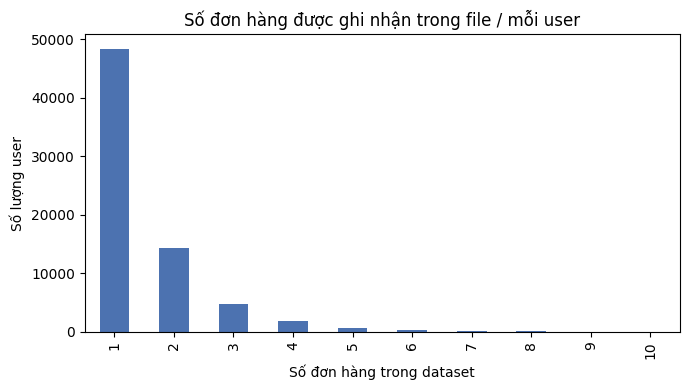

In [48]:
orders_per_user = df.groupby('user_id')['order_id'].nunique()
fig, ax = plt.subplots(figsize=(7,4))
orders_per_user.value_counts().sort_index().plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Số đơn hàng được ghi nhận trong file / mỗi user')
ax.set_xlabel('Số đơn hàng trong dataset')
ax.set_ylabel('Số lượng user')
plt.tight_layout()
plt.show()

# 3. Làm sạch dữ liệu

In [49]:
df_new = df.copy()
df_new['order_hour_of_day'] = pd.to_numeric(df_new['order_hour_of_day'], errors='coerce')
df_new['order_hour_of_day'].isnull().sum() 
 # kiểm tra lại xem còn giá trị bất thường nào không
df_new.dropna(subset=['order_hour_of_day'], inplace=True)
df_new.shape

(1048574, 12)

In [50]:
df_clean = df.copy()

# 3.1 Chuẩn hoá order_hour_of_day về numeric, loại bỏ dòng lỗi (rất ít, <0.01%)
df_clean['order_hour_of_day'] = pd.to_numeric(df_clean['order_hour_of_day'], errors='coerce')
before = len(df_clean)
df_clean.dropna(subset=['order_hour_of_day'],inplace=True)
print(f'Loại bỏ {before - len(df_clean)} dòng có order_hour_of_day không hợp lệ')

# 3.2 Gộp nhóm 'missing' vào 'other' cho department (giá trị placeholder, không phải NaN thật)
df_clean['department'] = df_clean['department'].replace({'missing': 'other'})

# 3.3 Kiểm tra khoảng giá trị hợp lệ
assert df_clean['order_hour_of_day'].between(0, 23).all()
assert df_clean['order_dow'].between(0, 6).all()
assert (df_clean['add_to_cart_order'] >= 1).all()
assert df_clean['reordered'].isin([0, 1]).all()

print('Shape sau khi làm sạch:', df_clean.shape)

Loại bỏ 1 dòng có order_hour_of_day không hợp lệ
Shape sau khi làm sạch: (1048574, 12)
